In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import datetime as datetime

In [9]:
# Load your dataset


file_path = 'data/F1_sample_data_with_random_consultoras.csv'  # Replace with your actual CSV file path
data = pd.read_csv(file_path)
print(data)

        CODEBELISTA  ANIOCAMPANA CODPAIS  CODPRODUCTOSAP      DESCATEGORIA  \
0          49958455       202302      PE       210100816        MAQUILLAJE   
1          50038750       202302      PE       200095170  CUIDADO PERSONAL   
2          26877393       202302      PE       200105125  CUIDADO PERSONAL   
3          48742556       202302      PE       200097066  CUIDADO PERSONAL   
4          49769164       202302      PE       200078924  CUIDADO PERSONAL   
...             ...          ...     ...             ...               ...   
168055     45658163       202418      PE       200105017        FRAGANCIAS   
168056     52166489       202418      PE       210103140            LENTES   
168057     52683025       202418      PE       200095931        FRAGANCIAS   
168058     52683025       202418      PE       200114054        MAQUILLAJE   
168059     52204089       202501      PE       210105381      COMPLEMENTOS   

       DESMARCA  PRECIOOFERTA FECHAPROCESO  
0         ESIKA   

In [10]:
df = pd.read_csv(file_path)
# df['CODEBELISTA'].value_counts()
df['CODEBELISTA'].nunique()

2097

In [11]:
# Convert FECHAPROCESO to datetime
data['FECHAPROCESO'] = pd.to_datetime(data['FECHAPROCESO'])

# Calculate Recency: Normalize such that 10 is the latest and 1 is the oldest for each consultora
latest_date = data['FECHAPROCESO'].max()
oldest_date = data['FECHAPROCESO'].min()

# For each consultora, calculate Recency and normalize it between 1 and 10
data['Recency'] = data.groupby('CODEBELISTA')['FECHAPROCESO'].transform(
    lambda x: 1 + 9 * ((latest_date - x).dt.days) / ((latest_date - oldest_date).days)
)

# Frequency by CODEBELISTA
frequency = data.groupby('CODEBELISTA').size().reset_index(name='Frequency')

# Normalize Frequency: Scale between 1 and 10
frequency['Frequency'] = 1 + 9 * (frequency['Frequency'] - frequency['Frequency'].min()) / (frequency['Frequency'].max() - frequency['Frequency'].min())

# Merge Frequency and Recency on CODEBELISTA
rf_data = pd.merge(frequency, data[['CODEBELISTA', 'Recency']].drop_duplicates(), on='CODEBELISTA')

# Final DataFrame
print(rf_data.head())


   CODEBELISTA  Frequency   Recency
0       227323   1.312655  7.464619
1       227323   1.312655  7.981308
2       227323   1.312655  9.567423
3      1058614   2.596774  7.440587
4      1058614   2.596774  7.152203


In [13]:
data['FECHAPROCESO'] = pd.to_datetime(data['FECHAPROCESO'])

# Calculate Recency: Normalize such that 10 is the latest and 1 is the oldest for each consultora
latest_date = data['FECHAPROCESO'].max()
oldest_date = data['FECHAPROCESO'].min()

# For each consultora, calculate Recency and normalize it between 1 and 10
data['Recency'] = data.groupby('CODEBELISTA')['FECHAPROCESO'].transform(
    lambda x: 1 + 9 * ((latest_date - x).dt.days) / ((latest_date - oldest_date).days)
)

# Frequency by CODEBELISTA
frequency = data.groupby('CODEBELISTA').size().reset_index(name='Frequency')

# Normalize Frequency: Scale between 1 and 10
frequency['Frequency'] = 1 + 9 * (frequency['Frequency'] - frequency['Frequency'].min()) / (frequency['Frequency'].max() - frequency['Frequency'].min())

# Aggregate other columns (take the first value per CODEBELISTA or use other aggregation methods)
agg_data = data.groupby('CODEBELISTA').agg(
    ANIOCAMPANA=('ANIOCAMPANA', 'first'),
    CODPRODUCTOSAP=('CODPRODUCTOSAP', 'first'),
    DESCATEGORIA=('DESCATEGORIA', 'first'),
    DESMARCA=('DESMARCA', 'first'),
    PRECIOOFERTA=('PRECIOOFERTA', 'first')
).reset_index()

# Merge Frequency and Recency on CODEBELISTA
rf_data = pd.merge(frequency, data[['CODEBELISTA', 'Recency']].drop_duplicates(), on='CODEBELISTA')
rf_data = pd.merge(rf_data, agg_data, on='CODEBELISTA')

# Final DataFrame
print(rf_data.head())

   CODEBELISTA  Frequency   Recency  ANIOCAMPANA  CODPRODUCTOSAP  \
0       227323   1.312655  7.464619       202310       200103726   
1       227323   1.312655  7.981308       202310       200103726   
2       227323   1.312655  9.567423       202310       200103726   
3      1058614   2.596774  7.440587       202310       210097089   
4      1058614   2.596774  7.152203       202310       210097089   

       DESCATEGORIA DESMARCA  PRECIOOFERTA  
0        MAQUILLAJE    ESIKA          26.9  
1        MAQUILLAJE    ESIKA          26.9  
2        MAQUILLAJE    ESIKA          26.9  
3  CUIDADO PERSONAL     LBEL          13.9  
4  CUIDADO PERSONAL     LBEL          13.9  


In [97]:
print(data)

        CODEBELISTA  ANIOCAMPANA CODPAIS  CODPRODUCTOSAP      DESCATEGORIA  \
0          49958455       202302      PE       210100816        MAQUILLAJE   
1          50038750       202302      PE       200095170  CUIDADO PERSONAL   
2          26877393       202302      PE       200105125  CUIDADO PERSONAL   
3          48742556       202302      PE       200097066  CUIDADO PERSONAL   
4          49769164       202302      PE       200078924  CUIDADO PERSONAL   
...             ...          ...     ...             ...               ...   
168055     45658163       202418      PE       200105017        FRAGANCIAS   
168056     52166489       202418      PE       210103140            LENTES   
168057     52683025       202418      PE       200095931        FRAGANCIAS   
168058     52683025       202418      PE       200114054        MAQUILLAJE   
168059     52204089       202501      PE       210105381      COMPLEMENTOS   

       DESMARCA  PRECIOOFERTA FECHAPROCESO    Recency  
0      

In [79]:
data['CODEBELISTA'].value_counts()

CODEBELISTA
38513095    807
31815142    797
45547477    769
48520766    677
43462830    661
           ... 
49932510      1
48279058      1
48984428      1
49830262      1
46847644      1
Name: count, Length: 2097, dtype: int64

In [21]:
print(rf_data)

       CODEBELISTA  Frequency   Recency  ANIOCAMPANA  CODPRODUCTOSAP  \
0           227323   1.312655  7.464619       202310       200103726   
1           227323   1.312655  7.981308       202310       200103726   
2           227323   1.312655  9.567423       202310       200103726   
3          1058614   2.596774  7.440587       202310       210097089   
4          1058614   2.596774  7.152203       202310       210097089   
...            ...        ...       ...          ...             ...   
15329     52941652   1.066998  1.516689       202417       200095430   
15330     52946301   1.122829  1.492657       202417       200115976   
15331     52969492   1.122829  1.348465       202417       210105843   
15332     52970393   1.089330  1.432577       202417       200111182   
15333     52977584   1.223325  1.420561       202417       200105071   

               DESCATEGORIA DESMARCA  PRECIOOFERTA  Combined_Score  \
0                MAQUILLAJE    ESIKA         26.90        4.69623

C:\Users\athar\AppData\Local\Temp\ipykernel_28876\1801250230.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = rf_data.groupby(['Frequency_bins', 'Recency_bins'])['PRECIOOFERTA'].sum().unstack()


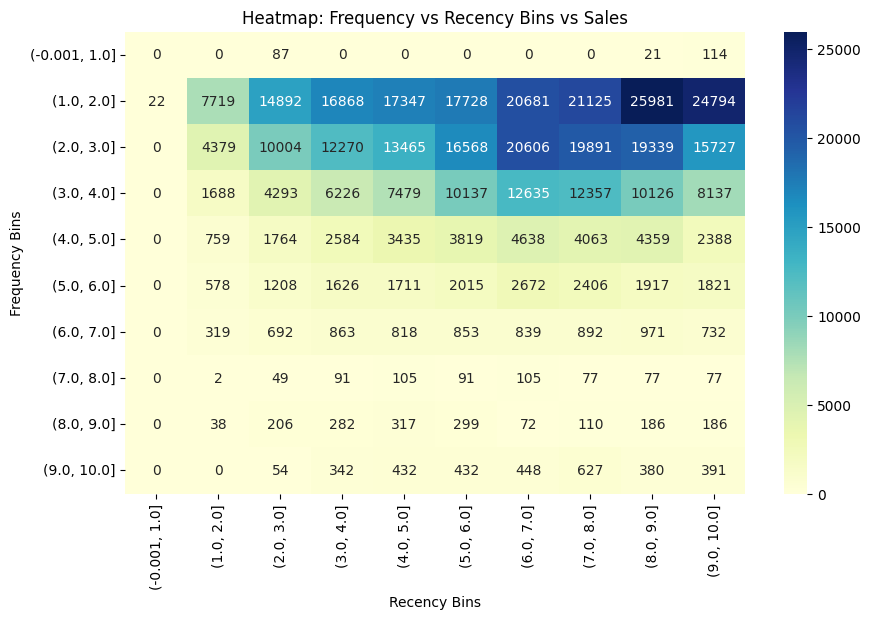

In [26]:
import seaborn as sns

bins_recency = np.arange(0, 11, 1)  # 10 bins for Recency
bins_frequency = np.arange(0, 11, 1)  # 10 bins for Frequency

# Create binned columns
rf_data['Recency_bins'] = pd.cut(rf_data['Recency'], bins=bins_recency, include_lowest=True)
rf_data['Frequency_bins'] = pd.cut(rf_data['Frequency'], bins=bins_frequency, include_lowest=True)

# Assuming df is your dataframe
heatmap_data = rf_data.groupby(['Frequency_bins', 'Recency_bins'])['PRECIOOFERTA'].sum().unstack()

# Plotting the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title('Heatmap: Frequency vs Recency Bins vs Sales')
plt.xlabel('Recency Bins')
plt.ylabel('Frequency Bins')
plt.show()

C:\Users\athar\AppData\Local\Temp\ipykernel_28876\1185892199.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = rf_data.groupby(['Frequency_bins', 'Recency_bins'])['PRECIOOFERTA'].mean().unstack()


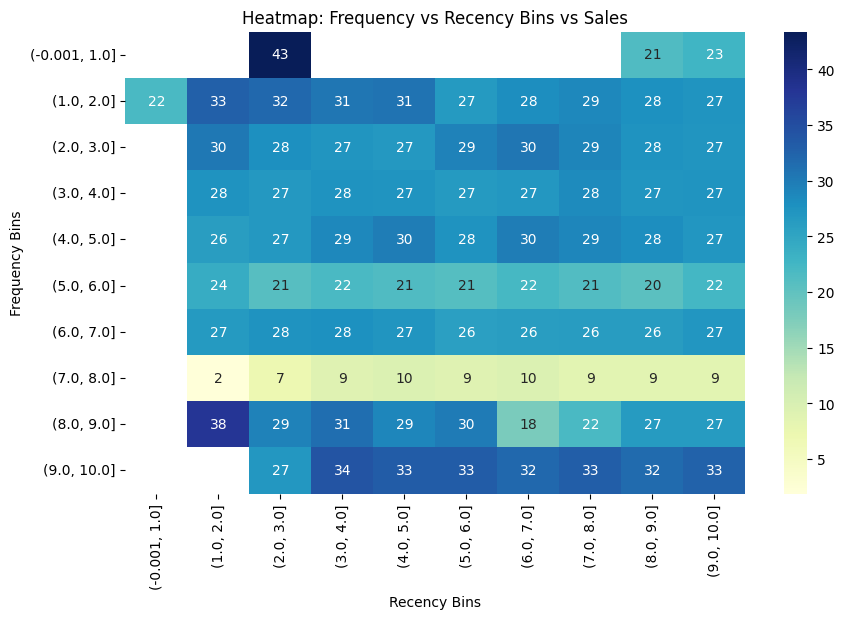

In [28]:
import seaborn as sns

bins_recency = np.arange(0, 11, 1)  # 10 bins for Recency
bins_frequency = np.arange(0, 11, 1)  # 10 bins for Frequency

# Create binned columns
rf_data['Recency_bins'] = pd.cut(rf_data['Recency'], bins=bins_recency, include_lowest=True)
rf_data['Frequency_bins'] = pd.cut(rf_data['Frequency'], bins=bins_frequency, include_lowest=True)

# Assuming df is your dataframe
heatmap_data = rf_data.groupby(['Frequency_bins', 'Recency_bins'])['PRECIOOFERTA'].mean().unstack()

# Plotting the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title('Heatmap: Frequency vs Recency Bins vs Sales')
plt.xlabel('Recency Bins')
plt.ylabel('Frequency Bins')
plt.show()

C:\Users\athar\AppData\Local\Temp\ipykernel_28876\652814671.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_counts = rf_data.groupby(['Recency_bins', 'Frequency_bins', 'PRECIOOFERTA']).size().reset_index(name='product_price')
C:\Users\athar\AppData\Local\Temp\ipykernel_28876\652814671.py:33: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_category_counts = category_counts.pivot_table(values='PRECIOOFERTA',


      Recency_bins Frequency_bins  PRECIOOFERTA  product_price
33000   (6.0, 7.0]     (6.0, 7.0]          0.02              0
33001   (6.0, 7.0]     (6.0, 7.0]          0.40              0
33002   (6.0, 7.0]     (6.0, 7.0]          0.74              0
33003   (6.0, 7.0]     (6.0, 7.0]          0.84              0
33004   (6.0, 7.0]     (6.0, 7.0]          0.90              0
...            ...            ...           ...            ...
33495   (6.0, 7.0]     (6.0, 7.0]        129.90              0
33496   (6.0, 7.0]     (6.0, 7.0]        134.90              0
33497   (6.0, 7.0]     (6.0, 7.0]        135.00              0
33498   (6.0, 7.0]     (6.0, 7.0]        139.90              0
33499   (6.0, 7.0]     (6.0, 7.0]        149.90              0

[500 rows x 4 columns]


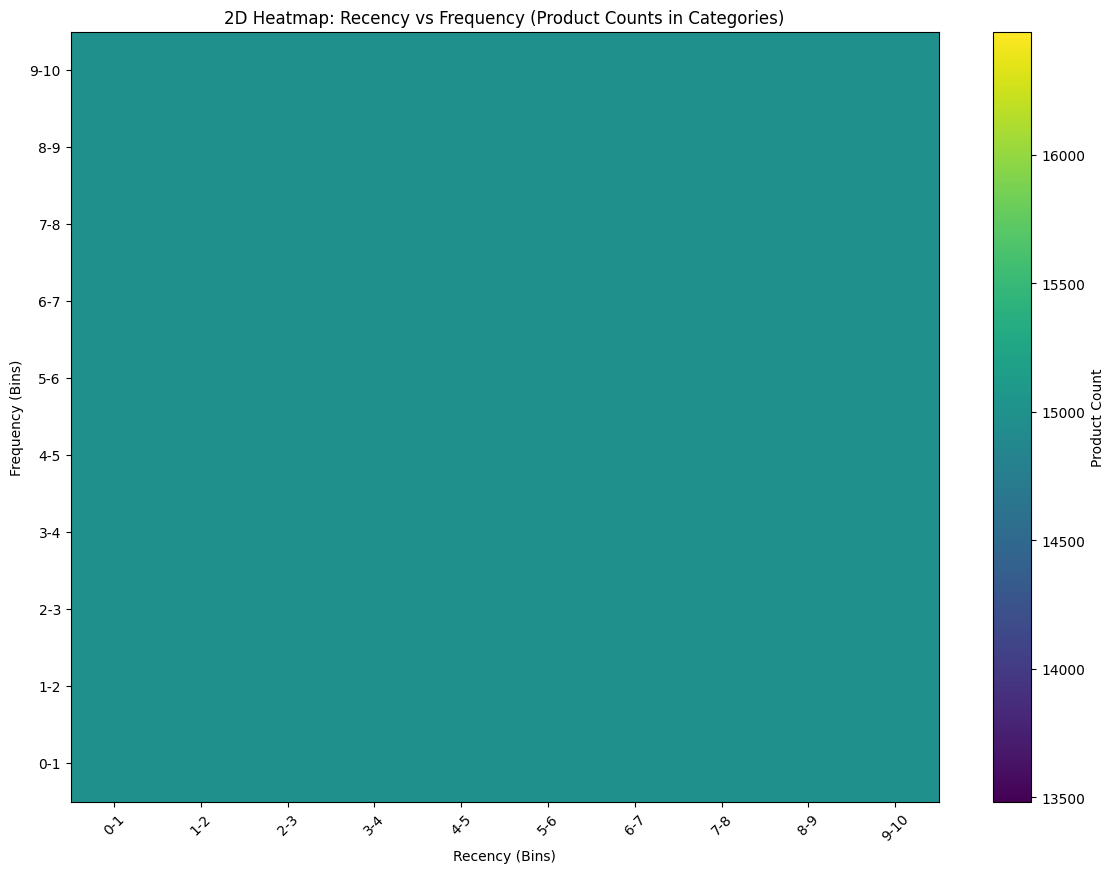

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assuming `rf_data` already contains the 'Recency_bins', 'Frequency_bins' and 'Category' columns

# Example: Ensure there's a 'Category' column to represent different product categories
# You should already have `DESCATEGORIA` from the previous steps, assuming it's the product category
# rf_data['Category'] = rf_data['DESCATEGORIA']
# rf_data['Product_price'] = rf_data['PRECIOOFERTA']

# rf_data.drop(columns=["Product_price"], inplace=True)

# Calculate Combined Score (you have already done this)
alpha, beta = 0.45, 0.55
rf_data['Combined_Score'] = alpha * rf_data['Frequency'] + beta * rf_data['Recency']

# Define bins explicitly for Recency and Frequency
bins_recency = np.arange(0, 11, 1)  # 10 bins for Recency
bins_frequency = np.arange(0, 11, 1)  # 10 bins for Frequency

# Create binned columns
rf_data['Recency_bins'] = pd.cut(rf_data['Recency'], bins=bins_recency, include_lowest=True)
rf_data['Frequency_bins'] = pd.cut(rf_data['Frequency'], bins=bins_frequency, include_lowest=True)

# Count the number of products in each category within each combination of Recency and Frequency bins
category_counts = rf_data.groupby(['Recency_bins', 'Frequency_bins', 'PRECIOOFERTA']).size().reset_index(name='product_price')

category_counts.to_csv('product_counts.csv', index=False)

# To get the count of products for each category within each Recency-Frequency bin
# You can pivot the data to show product counts in a more readable format
heatmap_category_counts = category_counts.pivot_table(values='PRECIOOFERTA', 
                                                      index='Frequency_bins', 
                                                      columns='Recency_bins', 
                                                      aggfunc='sum', 
                                                      fill_value=0)

# Print the category counts for a specific bin (e.g., for Recency bin 6-7 and Frequency bin 6-7)
# You can filter for a specific bin like below
specific_bin = category_counts[(category_counts['Recency_bins'] == pd.Interval(6, 7)) & 
                               (category_counts['Frequency_bins'] == pd.Interval(6, 7))]

print(specific_bin)

# Plot the heatmap of product counts by category
plt.figure(figsize=(14, 10))
plt.imshow(heatmap_category_counts, aspect='auto', cmap='viridis', origin='lower')
plt.colorbar(label='Product Count')
plt.title('2D Heatmap: Recency vs Frequency (Product Counts in Categories)')

# Proper axis labels
plt.xlabel('Recency (Bins)')
plt.ylabel('Frequency (Bins)')
plt.xticks(range(len(heatmap_category_counts.columns)), 
           [f"{int(bin.left)}-{int(bin.right)}" for bin in heatmap_category_counts.columns.categories], rotation=45)
plt.yticks(range(len(heatmap_category_counts.index)), 
           [f"{int(bin.left)}-{int(bin.right)}" for bin in heatmap_category_counts.index.categories])

plt.show()


C:\Users\athar\AppData\Local\Temp\ipykernel_32264\2833654244.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_counts = rf_data.groupby(['Recency_bins', 'Frequency_bins', 'Category']).size().reset_index(name='Product_Count')
C:\Users\athar\AppData\Local\Temp\ipykernel_32264\2833654244.py:26: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_category_counts = category_counts.pivot_table(values='Product_Count',


Category counts have been saved to 'category_counts.csv'.


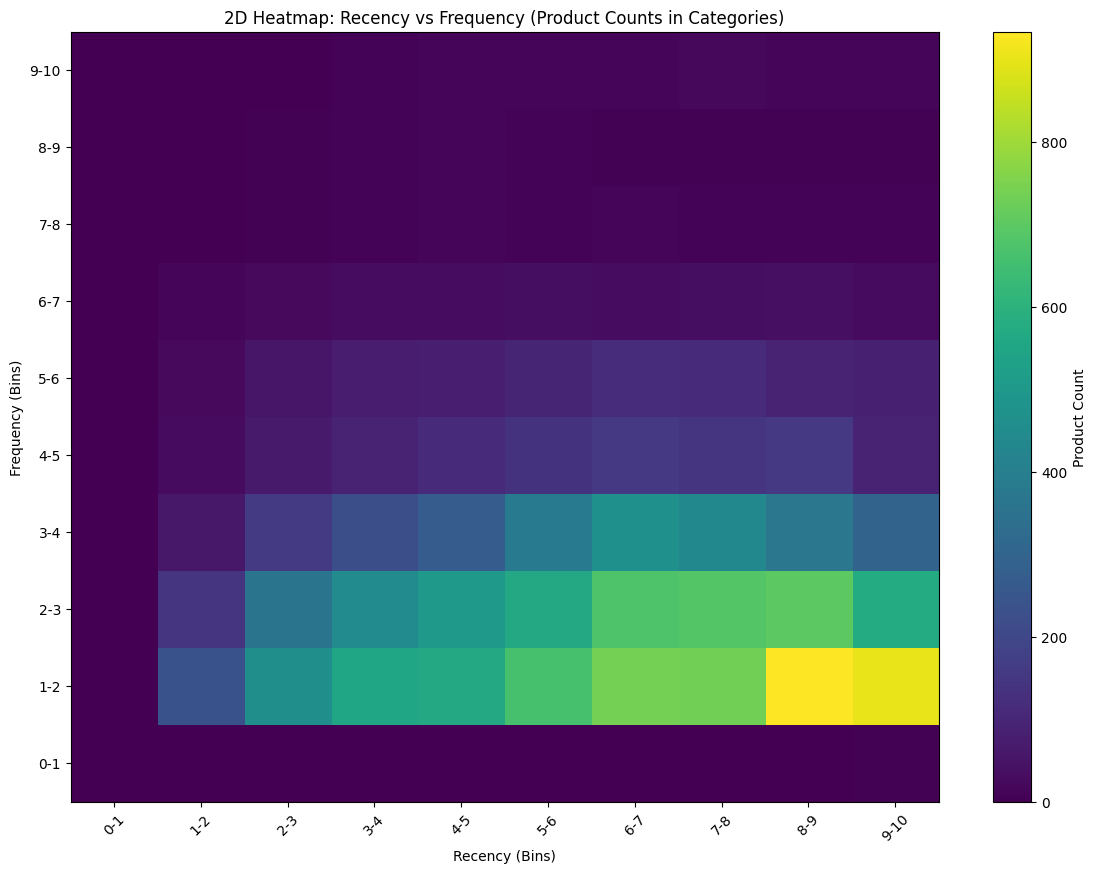

In [112]:
# Assuming `rf_data` already contains the 'Recency_bins', 'Frequency_bins' and 'Category' columns

# Example: Ensure there's a 'Category' column to represent different product categories
# You should already have `DESCATEGORIA` from the previous steps, assuming it's the product category
rf_data['Category'] = rf_data['DESCATEGORIA']

# Calculate Combined Score (you have already done this)
alpha, beta = 0.5, 0.5
rf_data['Combined_Score'] = alpha * rf_data['Frequency'] + beta * rf_data['Recency']

# Define bins explicitly for Recency and Frequency
bins_recency = np.arange(0, 11, 1)  # 10 bins for Recency
bins_frequency = np.arange(0, 11, 1)  # 10 bins for Frequency

# Create binned columns
rf_data['Recency_bins'] = pd.cut(rf_data['Recency'], bins=bins_recency, include_lowest=True)
rf_data['Frequency_bins'] = pd.cut(rf_data['Frequency'], bins=bins_frequency, include_lowest=True)

# Count the number of products in each category within each combination of Recency and Frequency bins
category_counts = rf_data.groupby(['Recency_bins', 'Frequency_bins', 'Category']).size().reset_index(name='Product_Count')

# Save the category counts to a CSV file
category_counts.to_csv('category_counts.csv', index=False)

# Optionally, you can also create a pivot table for easier analysis or visualization
heatmap_category_counts = category_counts.pivot_table(values='Product_Count', 
                                                      index='Frequency_bins', 
                                                      columns='Recency_bins', 
                                                      aggfunc='sum', 
                                                      fill_value=0)

# Print a message indicating that the file has been saved
print("Category counts have been saved to 'category_counts.csv'.")

# Plot the heatmap of product counts by category
plt.figure(figsize=(14, 10))
plt.imshow(heatmap_category_counts, aspect='auto', cmap='viridis', origin='lower')
plt.colorbar(label='Product Count')
plt.title('2D Heatmap: Recency vs Frequency (Product Counts in Categories)')

# Proper axis labels
plt.xlabel('Recency (Bins)')
plt.ylabel('Frequency (Bins)')
plt.xticks(range(len(heatmap_category_counts.columns)), 
           [f"{int(bin.left)}-{int(bin.right)}" for bin in heatmap_category_counts.columns.categories], rotation=45)
plt.yticks(range(len(heatmap_category_counts.index)), 
           [f"{int(bin.left)}-{int(bin.right)}" for bin in heatmap_category_counts.index.categories])

plt.show()


In [146]:
print(df.head)

<bound method NDFrame.head of        CODEBELISTA  Frequency   Recency  Combined_Score Recency_bins  \
0           227323   1.312655  7.464619        2.714088   (7.0, 8.0]   
1           227323   1.312655  7.981308        2.839850   (7.0, 8.0]   
2           227323   1.312655  9.567423        3.225911  (9.0, 10.0]   
3          1058614   2.596774  7.440587        3.585934   (7.0, 8.0]   
4          1058614   2.596774  7.152203        3.515741   (7.0, 8.0]   
...            ...        ...       ...             ...          ...   
15329     52941652   1.066998  1.516689        1.098455   (1.0, 2.0]   
15330     52946301   1.122829  1.492657        1.130766   (1.0, 2.0]   
15331     52969492   1.122829  1.348465        1.095670   (1.0, 2.0]   
15332     52970393   1.089330  1.432577        1.093246   (1.0, 2.0]   
15333     52977584   1.223325  1.420561        1.181907   (1.0, 2.0]   

      Frequency_bins  
0         (1.0, 2.0]  
1         (1.0, 2.0]  
2         (1.0, 2.0]  
3         (2.

In [ ]:
# Assuming `rf_data` already contains the 'Recency_bins', 'Frequency_bins' and 'Category' columns

# Example: Ensure there's a 'Category' column to represent different product categories
# You should already have `DESCATEGORIA` from the previous steps, assuming it's the product category
rf_data['Category'] = rf_data['DESCATEGORIA']

# Calculate Combined Score (you have already done this)
alpha, beta = 0.5, 0.5
rf_data['Combined_Score'] = alpha * rf_data['Frequency'] + beta * rf_data['Recency']

# Define bins explicitly for Recency and Frequency
bins_recency = np.arange(0, 11, 1)  # 10 bins for Recency
bins_frequency = np.arange(0, 11, 1)  # 10 bins for Frequency

# Create binned columns
rf_data['Recency_bins'] = pd.cut(rf_data['Recency'], bins=bins_recency, include_lowest=True)
rf_data['Frequency_bins'] = pd.cut(rf_data['Frequency'], bins=bins_frequency, include_lowest=True)

# Count the number of products in each category within each combination of Recency and Frequency bins
category_counts = rf_data.groupby(['Recency_bins', 'Frequency_bins', 'Category']).size().reset_index(name='Product_Count')

# Save the category counts to a CSV file
category_counts.to_csv('category_counts.csv', index=False)

# Optionally, you can also create a pivot table for easier analysis or visualization
heatmap_category_counts = category_counts.pivot_table(values='Product_Count', 
                                                      index='Frequency_bins', 
                                                      columns='Recency_bins', 
                                                      aggfunc='sum', 
                                                      fill_value=0)

# Print a message indicating that the file has been saved
print("Category counts have been saved to 'category_counts.csv'.")

# Plot the heatmap of product counts by category
plt.figure(figsize=(14, 10))
plt.imshow(heatmap_category_counts, aspect='auto', cmap='viridis', origin='lower')
plt.colorbar(label='Product Count')
plt.title('2D Heatmap: Recency vs Frequency (Product Counts in Categories)')

# Proper axis labels
plt.xlabel('Recency (Bins)')
plt.ylabel('Frequency (Bins)')
plt.xticks(range(len(heatmap_category_counts.columns)), 
           [f"{int(bin.left)}-{int(bin.right)}" for bin in heatmap_category_counts.columns.categories], rotation=45)
plt.yticks(range(len(heatmap_category_counts.index)), 
           [f"{int(bin.left)}-{int(bin.right)}" for bin in heatmap_category_counts.index.categories])

plt.show()


In [53]:
# Generate synthetic data
np.random.seed(42)
num_records = 500  # Number of records
dummy_data = pd.DataFrame({
    'Frequency': np.random.randint(1, 11, size=num_records),  # Random values between 1 and 10
    'Recency': np.random.uniform(1, 10, size=num_records),   # Random values between 1 and 10
})

# Normalize Recency
dummy_data['Recency'] = 10 - dummy_data['Recency']  # Higher recency is better (lower value)

C:\Users\athar\AppData\Local\Temp\ipykernel_32264\4182648959.py:14: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = dummy_data.pivot_table(


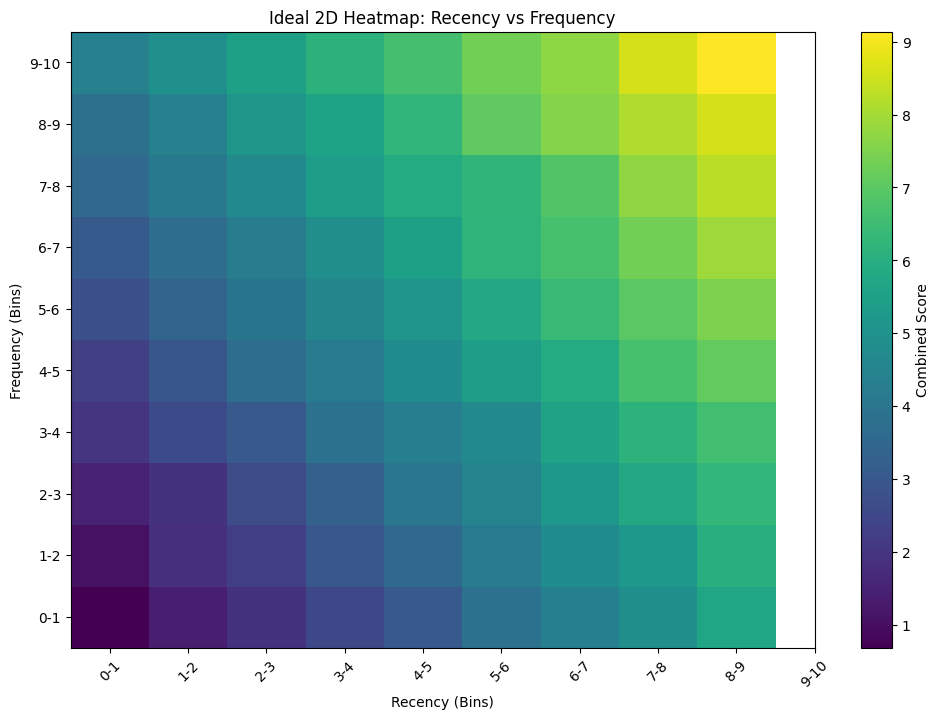

In [114]:
# Assign alpha and beta weights
alpha, beta = 0.4, 0.6
dummy_data['Combined_Score'] = alpha * dummy_data['Frequency'] + beta * dummy_data['Recency']

# Define bins
bins_recency = np.arange(0, 11, 1)  # 10 bins for Recency (0-10)
bins_frequency = np.arange(0, 11, 1)  # 10 bins for Frequency (0-10)

# Binning Recency and Frequency
dummy_data['Recency_bins'] = pd.cut(dummy_data['Recency'], bins=bins_recency, include_lowest=True)
dummy_data['Frequency_bins'] = pd.cut(dummy_data['Frequency'], bins=bins_frequency, include_lowest=True)

# Create pivot table for heatmap
heatmap_data = dummy_data.pivot_table(
    values='Combined_Score',
    index='Frequency_bins',
    columns='Recency_bins',
    aggfunc='mean'
)

# Generate bin labels
recency_labels = [f"{int(bin.left)}-{int(bin.right)}" for bin in heatmap_data.columns.categories]
frequency_labels = [f"{int(bin.left)}-{int(bin.right)}" for bin in heatmap_data.index.categories]

# Plot heatmap
plt.figure(figsize=(12, 8))
plt.imshow(heatmap_data, aspect='auto', cmap='viridis', origin='lower')
plt.colorbar(label='Combined Score')
plt.title('Ideal 2D Heatmap: Recency vs Frequency')

# Add labels
plt.xlabel('Recency (Bins)')
plt.ylabel('Frequency (Bins)')
plt.xticks(range(len(recency_labels)), recency_labels, rotation=45)
plt.yticks(range(len(frequency_labels)), frequency_labels)

plt.show()


# for 0.5 and 0.5

recency = 8.5, frequency = 9.5
alpha = 0.5, beta = 0.5 

Panchor = 0.5 * 9.5 + 0.5 * 8.5 
        = 4.75 +  4.25
        = 9 (heighest in the overall map)

# for 0.4 and 0.6 

recency = 8.5, frequency = 9.5, alpha = 0.4, beta = 0.6

Panchor = 0.4 * 9.5 + 0.6 * 8.5 = 3.8 + 5.1 = 8.9

# for 0.3 nd 0.7
recency = 8.5, frequency = 9.5, alpha = 0.3, beta = 0.7 

Panchor = 0.3 * 9.5 + 0.7 * 8.5 = 2.85 + 5.95 = 8.8

In [126]:
import numpy as np
from scipy.optimize import minimize

# Example dataset (replace with your data)
frequency = np.array(rf_data['Frequency'])
recency = np.array(rf_data['Recency'])

# Objective function: negative normalized Combined Score (to maximize)
def objective(weights):
    alpha, beta = weights
    combined_score = (alpha * frequency + beta * recency)
    # Normalize the combined score to ensure it is less than 1
    normalized_score = combined_score / (alpha * frequency.max() + beta * recency.max())
    return -np.sum(normalized_score)  # Negative because we use minimization

# Constraints: alpha + beta = 1
constraints = [{'type': 'eq', 'fun': lambda weights: weights[0] + weights[1] - 1}]

# Bounds: alpha > 0, beta > 0 (slightly above 0 to avoid exactly 0)
epsilon = 1e-6
bounds = [(epsilon, 1), (epsilon, 1)]

# Initial guess
initial_weights = [0.5, 0.5]

# Optimization
result = minimize(objective, initial_weights, bounds=bounds, constraints=constraints)

# Extract optimal weights
optimal_alpha, optimal_beta = result.x
print(f"Optimal alpha: {optimal_alpha:.6f}")
print(f"Optimal beta: {optimal_beta:.6f}")

# Calculate maximum normalized combined score
max_combined_score = -result.fun
print(f"Maximum Normalized Combined Score: {max_combined_score:.6f}")

# Verify that all scores are less than 1
combined_score = (optimal_alpha * frequency + optimal_beta * recency)
normalized_score = combined_score / (optimal_alpha * frequency.max() + optimal_beta * recency.max())
print(f"All normalized scores < 1: {np.all(normalized_score < 1)}")


Optimal alpha: 0.000001
Optimal beta: 1.000000
Maximum Normalized Combined Score: 9604.034633
All normalized scores < 1: True


### combined score using entropy based weight adjustment approach 

In [142]:
import numpy as np
import pandas as pd

df = pd.DataFrame(rf_data)

# Step 1: Normalize the data
normalized_data = (df - df.min()) / (df.max() - df.min())

# Step 2: Calculate proportions
proportions = normalized_data.div(normalized_data.sum(axis=0), axis=1)

# Step 3: Calculate entropy for each attribute
k = 1 / np.log(len(df))
entropy = -k * (proportions * np.log(proportions + 1e-12)).sum(axis=0)

# Step 4: Calculate degree of diversification
diversification = 1 - entropy

# Step 5: Compute weights
weights = diversification / diversification.sum()

# Extract alpha and beta
alpha, beta = weights['Frequency'], weights['Recency']
print(f"Alpha (Weight for Frequency): {alpha:.4f}")
print(f"Beta (Weight for Recency): {beta:.4f}")

# Combined score
df['Combined_Score'] = alpha * df['Frequency'] + beta * df['Recency']
print(df['Combined_Score'].head())


TypeError: Object with dtype category cannot perform the numpy op subtract

In [136]:
print(rf_data.head)

<bound method NDFrame.head of        CODEBELISTA  Frequency   Recency
0           227323   1.312655  7.464619
1           227323   1.312655  7.981308
2           227323   1.312655  9.567423
3          1058614   2.596774  7.440587
4          1058614   2.596774  7.152203
...            ...        ...       ...
15329     52941652   1.066998  1.516689
15330     52946301   1.122829  1.492657
15331     52969492   1.122829  1.348465
15332     52970393   1.089330  1.432577
15333     52977584   1.223325  1.420561

[15334 rows x 3 columns]>
